# KIT Automotive OBD-II Cleaning and Data Quality Assessment Report

## Overview

This report presents the final validation results of the cleaned KIT automotive OBD-II dataset. The report integrates two complementary validation perspectives:

- **Internal Audit**: rule-based cleaning verification produced directly by the cleaning pipeline.
- **External Validation**: independent statistical and structural quality assessment conducted on the cleaned outputs.

This dual-layer framework ensures both deterministic compliance with predefined cleaning rules and independent verification of data integrity, temporal consistency, physical plausibility, and statistical stability.

## Final Conclusion

A comprehensive validation was conducted across six core quality dimensions. The cleaned dataset satisfies all predefined engineering contracts and exhibits strong consistency across structural, temporal, and statistical perspectives.

The overall data quality is considered acceptable for downstream predictive modeling and analytical tasks.

## Optimization Recommendation

To further improve temporal consistency and cross-source interoperability, it is recommended to standardize all timestamps to Coordinated Universal Time (UTC).

The original raw files contain local timezone offsets (e.g., `+02:00`), which may introduce potential ordering ambiguities when integrating data across multiple trips or regions. Standardizing timestamps to UTC provides a unified chronological baseline for subsequent analysis.

## 1. Schema Validation and Core Structural Integrity

This section verifies the structural correctness of the cleaned dataset against the expected pipeline schema.

The assessment focuses on:

- consistency of trip and segment counts;
- validation of required feature columns;
- detection of missing or unexpected fields;
- verification of composite key uniqueness.

The composite key `[trip_id, segment_id, timestamp]` is treated as the primary identity contract for all observations.

This step ensures that the cleaned dataset preserves the expected structural layout and remains compatible with downstream modeling pipelines.

In [30]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

path_candidates = [Path.cwd(), *Path.cwd().rglob("project_paths.py")]
for candidate in path_candidates:
    cleaning_dir = candidate if candidate.is_dir() else candidate.parent
    if (cleaning_dir / "project_paths.py").exists():
        sys.path.insert(0, str(cleaning_dir.resolve()))
        break
else:
    raise FileNotFoundError("Could not find project_paths.py from the current workspace.")

from project_paths import (
    CONFIG_PATH,
    CLEANED_DATASET,
    ENRICHED_DATASET,
    QUALITY_CSV,
    REPORT_JSON,
    REPO_ROOT,
)
from cleaning_core import (
    build_output_columns,
    build_quality_output_columns,
    discover_input_files,
    load_config,
)
from data_cleaning import run_cleaning
from quality_audit import run_quality_audit

config = load_config(CONFIG_PATH)
cleaned, cleaning_summary = run_cleaning(config)
quality, audit_report = run_quality_audit(config)

print("=== Pipeline Execution Summary ===")
print("Pipeline version:", config["version"])
print(f"Processed files: {cleaning_summary['files_processed']}")
print(f"Input rows:      {cleaning_summary['input_rows']:,}")
print(f"Output rows:     {cleaning_summary['output_rows']:,}")
print(f"Trips:           {cleaning_summary['trips']}")
print(f"Segments:        {cleaning_summary['segments']}")
display(cleaned.head())

=== Pipeline Execution Summary ===
Pipeline version: 3.0
Processed files: 81
Input rows:      2,693,824
Output rows:     249,694
Trips:           81
Segments:        118


,timestamp,trip_id,segment_id,row_in_segment,coolant_temp,map,rpm,speed,intake_temp,maf,tps,ambient_temp,accel_pedal_d,accel_pedal_e
0,2017-07-05T05:16:30Z,trip_0001,trip_0001_seg_001,1,31.0,96.0,0.0,0.0,22.0,0.91,89.0,NaN,NaN,NaN
1,2017-07-05T05:16:31Z,trip_0001,trip_0001_seg_001,2,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
2,2017-07-05T05:16:32Z,trip_0001,trip_0001_seg_001,3,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
3,2017-07-05T05:16:33Z,trip_0001,trip_0001_seg_001,4,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
4,2017-07-05T05:16:34Z,trip_0001,trip_0001_seg_001,5,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5


In [31]:
print("=== Dataset Overview ===")
print("Cleaned Shape:", cleaned.shape)
print("Quality Shape:", quality.shape)
print("Unique trips:", cleaned['trip_id'].nunique())
print("Unique segments:", cleaned['segment_id'].nunique())


cleaned['timestamp'] = pd.to_datetime(cleaned['timestamp'], utc=True)
quality['timestamp'] = pd.to_datetime(quality['timestamp'], utc=True)

expected_model_columns = build_output_columns(config)
expected_quality_columns = build_quality_output_columns(config)

missing_cols = set(expected_model_columns) - set(cleaned.columns)
extra_cols = set(cleaned.columns) - set(expected_model_columns) - {'dt'}
print("Missing columns:", missing_cols)
print("Extra columns (excluding 'dt'):", extra_cols)

print("Cleaned Timestamp Monotonic:", cleaned['timestamp'].is_monotonic_increasing)
print("Timestamp Range:", cleaned['timestamp'].min(), "→", cleaned['timestamp'].max())

cleaned_cols_to_check = [col for col in cleaned.columns if col != 'dt']
assert cleaned_cols_to_check == expected_model_columns, "Model columns mismatch (even without 'dt')"
assert list(quality.columns) == expected_quality_columns, "Quality columns mismatch"

key_columns = ["trip_id", "segment_id", "timestamp"]
assert not cleaned.duplicated(key_columns).any(), "Cleaned has duplicates"
assert not quality.duplicated(key_columns).any(), "Quality has duplicates"
assert len(cleaned) == len(quality), "Length mismatch"

=== Dataset Overview ===
Cleaned Shape: (249694, 14)
Quality Shape: (249694, 50)
Unique trips: 81
Unique segments: 118
Missing columns: set()
Extra columns (excluding 'dt'): set()
Cleaned Timestamp Monotonic: True
Timestamp Range: 2017-07-05 05:16:30+00:00 → 2018-04-23 18:13:53+00:00


## 2. Temporal Integrity and Continuity Validation

This section evaluates the temporal consistency of the cleaned time-series data.

The validation includes:

- strict one-second sampling interval verification;
- monotonic timestamp progression within each segment;
- detection of temporal discontinuities;
- verification of row index continuity.

Special attention is given to timestamp gaps greater than 1.5 seconds, which may indicate sensor interruptions, logging failures, or communication loss.

Under normal operating conditions, continuity is expected to be maintained within each segment, while discontinuities should only occur at segment boundaries.

In [32]:
dup_count = cleaned.duplicated(subset=['trip_id','segment_id','row_in_segment']).sum()
print("Duplicate rows (by row_in_segment):", dup_count)

def check_row_continuity(group):
    return group['row_in_segment'].is_monotonic_increasing
result = cleaned.groupby(['trip_id','segment_id']).apply(check_row_continuity)
print("Segments with broken row order:", (~result).sum())


cleaned['dt'] = cleaned.groupby(['trip_id','segment_id'])['timestamp'].diff().dt.total_seconds()
print("\n--- Time Delta (dt) Description ---")
print(cleaned['dt'].describe())
print("\nTop dt value counts:")
print(cleaned['dt'].value_counts().head())

gaps = cleaned[cleaned['dt'] > 1.5]
print(f"\nNumber of gaps (> 1.5s): {len(gaps)}")
if len(gaps) > 0:
    display(gaps.head())

Duplicate rows (by row_in_segment): 0
Segments with broken row order: 0

--- Time Delta (dt) Description ---
count    249576.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: dt, dtype: float64

Top dt value counts:
dt
1.0    249576
Name: count, dtype: int64

Number of gaps (> 1.5s): 0


## 3. External Validation: Missingness, Physical Consistency, and Statistical Integrity

This section presents an integrated external validation of the cleaned dataset, covering missing value structure, physical plausibility, cross-signal consistency, and statistical behavior.

The objective is to independently verify that the dataset is not only structurally valid, but also physically and statistically coherent.

In [33]:
quality_rows = []
for field, spec in config["fields"].items():
    non_missing = cleaned[field].dropna()
    
    z = (cleaned[field] - cleaned[field].mean()) / cleaned[field].std()
    z_outliers_count = int((np.abs(z) > 3).sum())
    
    quality_rows.append({
        "field": field,
        "unit": spec["unit"],
        "min": non_missing.min() if len(non_missing) else None,
        "max": non_missing.max() if len(non_missing) else None,
        "remaining_missing": int(cleaned[field].isna().sum()),
        "missing_rate": f"{cleaned[field].isna().mean():.4%}",
        "z_outliers (Z>3)": z_outliers_count,
        "imputed_by_pipeline": int(quality[f"{field}_is_imputed"].sum()),
        "suspicious_by_pipeline": int(quality[f"{field}_is_suspicious"].sum()),
    })

quality_summary = pd.DataFrame(quality_rows)
print("=== Field-Level Quality Matrix ===")
display(quality_summary)


print("Rows with any imputation:", int(quality["is_imputed_any"].sum()))
print("Rows with any suspicious value:", int(quality["is_suspicious_any"].sum()))


print("\n=== Domain Specific Anomalies ===")

coolant_diff = cleaned['coolant_temp'].diff().abs()
print("Abnormal coolant temp jumps (>30°C):", len(cleaned[coolant_diff > 30]))


rpm_z = (cleaned['rpm'] - cleaned['rpm'].mean()) / cleaned['rpm'].std()
print("\nSuspicious RPM rows stats (Z > 3):")
display(cleaned[np.abs(rpm_z) > 3]['rpm'].describe())

print("\nOutliers count per trip_id (Top 5):")
display(cleaned[np.abs(rpm_z) > 3].groupby('trip_id').size().sort_values(ascending=False).head(5))


print("\nMean speed per trip_id (Top 5):")
display(cleaned.groupby('trip_id')['speed'].mean().head(5))

=== Field-Level Quality Matrix ===


,field,unit,min,max,remaining_missing,missing_rate,z_outliers (Z>3),imputed_by_pipeline,suspicious_by_pipeline
0,coolant_temp,°C,-1.0,103.00,1,0.0004%,6192,56,0
1,map,kPa,36.0,247.00,3,0.0012%,4454,56,0
2,rpm,rpm,0.0,4315.00,7,0.0028%,637,56,0
3,speed,km/h,0.0,218.00,12,0.0048%,108,56,0
4,intake_temp,°C,-40.0,150.00,19,0.0076%,6328,56,3470
5,maf,g/s,0.0,129.22,24,0.0096%,4866,56,0
6,tps,%,13.7,89.00,32,0.0128%,10564,56,0
7,ambient_temp,°C,-14.0,33.00,94,0.0376%,0,0,0
8,accel_pedal_d,%,14.1,85.10,50,0.0200%,3955,56,0
9,accel_pedal_e,%,14.1,84.30,60,0.0240%,3993,56,0


Rows with any imputation: 56
Rows with any suspicious value: 3470

=== Domain Specific Anomalies ===
Abnormal coolant temp jumps (>30°C): 69

Suspicious RPM rows stats (Z > 3):


count     637.000000
mean     3274.638932
std       140.651466
min      3105.000000
25%      3167.000000
50%      3244.000000
75%      3337.000000
max      4315.000000
Name: rpm, dtype: float64


Outliers count per trip_id (Top 5):


trip_id
trip_0032    133
trip_0014     92
trip_0027     62
trip_0033     50
trip_0079     47
dtype: int64


Mean speed per trip_id (Top 5):


trip_id
trip_0001    49.546629
trip_0002    78.112850
trip_0003    25.000646
trip_0004    75.057309
trip_0005    60.487496
Name: speed, dtype: float64

## 4. Global Signal Visualization

To support qualitative inspection of overall data quality, this section visualizes the full time-series distributions of key engine signals, including:

- vehicle speed;
- engine RPM;
- coolant temperature;
- throttle position.

The purpose of this visualization is to identify large-scale abnormal patterns, signal interruptions, or systematic drift that may not be captured by rule-based or statistical checks alone.

For readability, the time axis may be compressed during rendering without affecting the underlying temporal resolution.

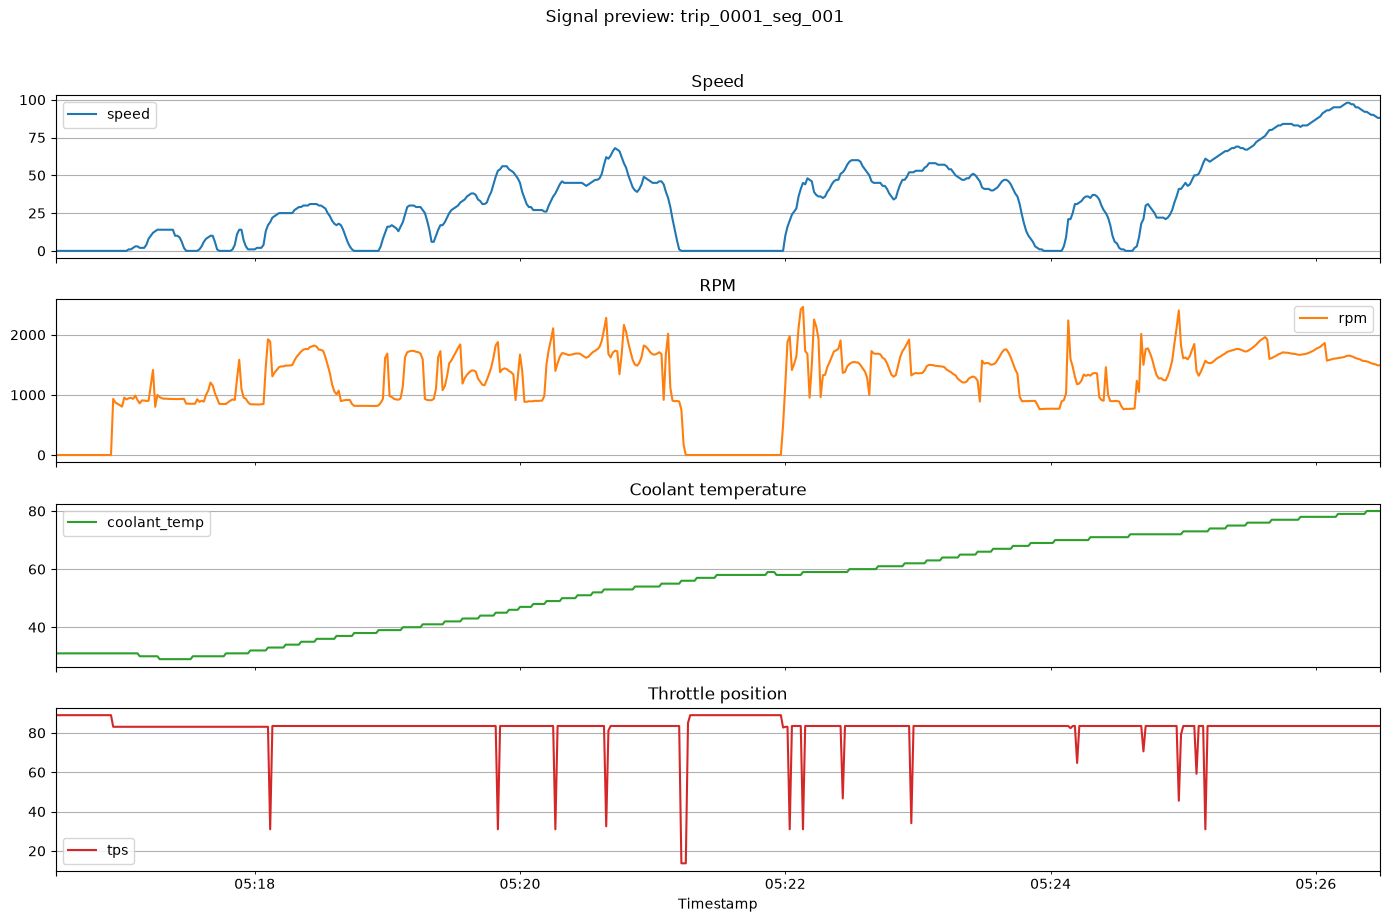

In [34]:
import matplotlib.pyplot as plt

try:
    preview_segment = cleaned["segment_id"].iloc[0]
    preview = cleaned.loc[cleaned["segment_id"].eq(preview_segment)].head(600).copy()
    preview = preview.set_index("timestamp")

    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]
    axes = preview[signal_columns].plot(
        subplots=True,
        figsize=(14, 9),
        title=["Speed", "RPM", "Coolant temperature", "Throttle position"],
        grid=True,
    )
    for axis in axes:
        axis.set_xlabel("Timestamp")
    plt.suptitle(f"Signal preview: {preview_segment}", y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Visual preview skipped: {exc}")

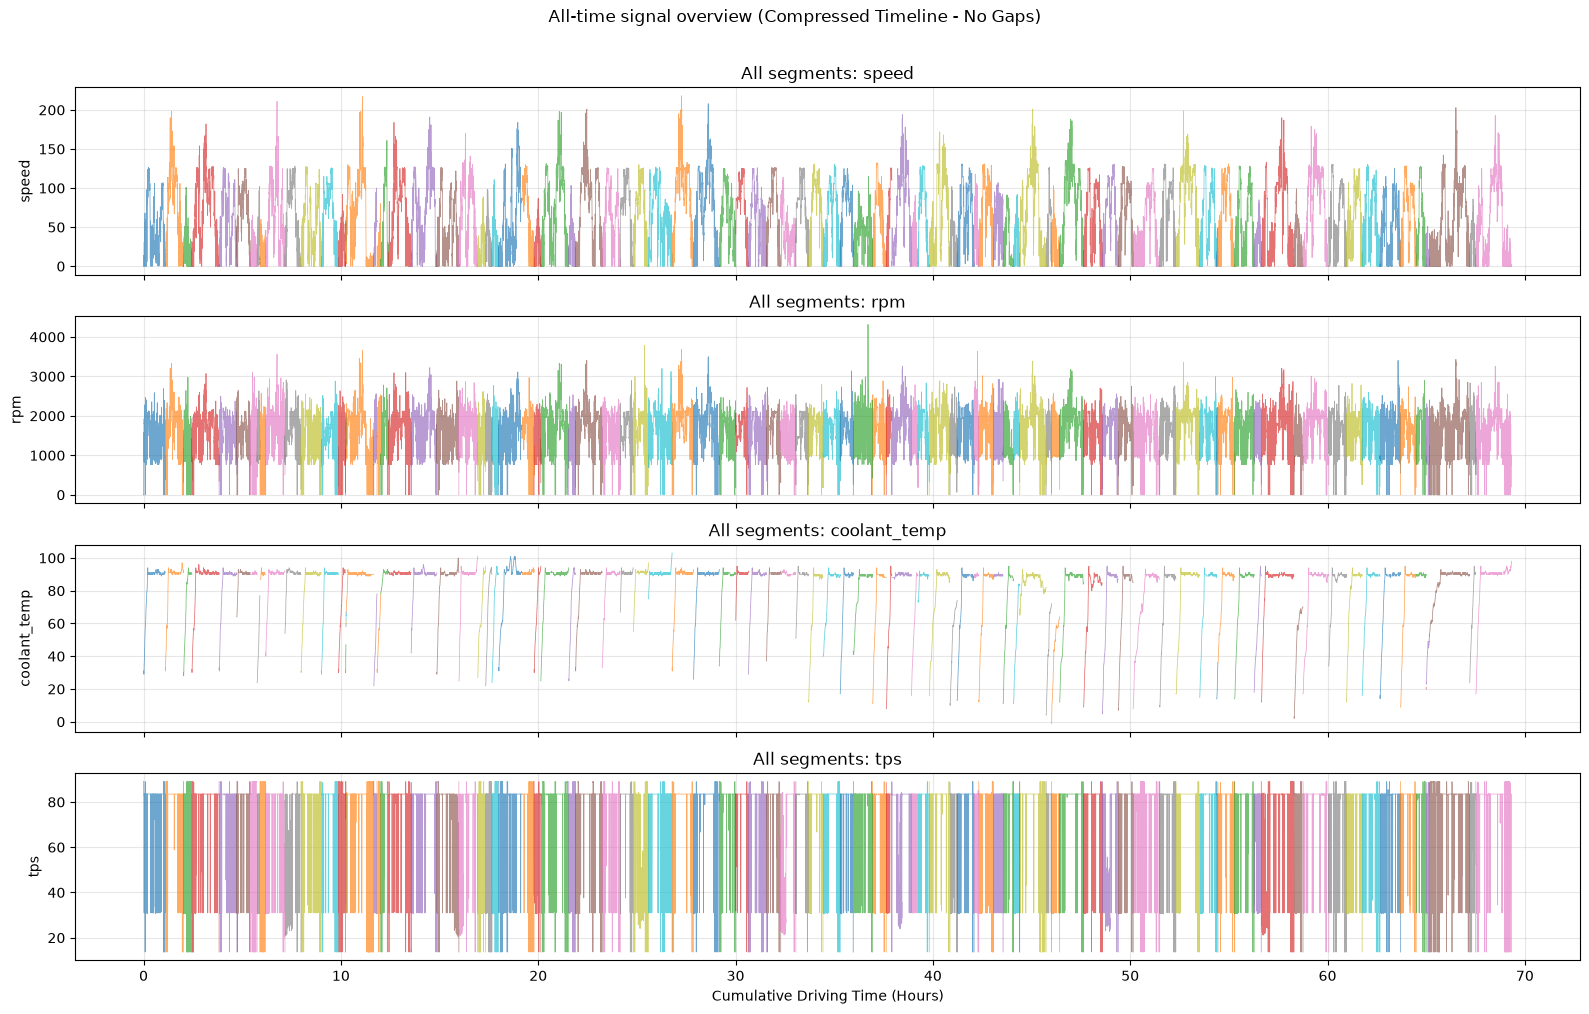

In [35]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "cleaned" not in globals():
        cleaned = pd.read_csv(CLEANED_DATASET)

    overview = cleaned.copy()
    overview["timestamp"] = pd.to_datetime(overview["timestamp"], utc=True)
    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]

    overview["segment_secs"] = overview.groupby("segment_id")["timestamp"].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    
    segment_durations = overview.groupby("segment_id")["segment_secs"].max()
    segment_offsets = segment_durations.cumsum().shift(1, fill_value=0)
    
    overview["continuous_secs"] = overview["segment_secs"] + overview["segment_id"].map(segment_offsets)
    
    fig, axes = plt.subplots(
        len(signal_columns),
        1,
        figsize=(16, 10),
        sharex=True,
    )


    for axis, column in zip(axes, signal_columns):
        for _, segment in overview.groupby("segment_id", sort=False):
            axis.plot(
                segment["continuous_secs"] / 3600, 
                segment[column],
                linewidth=0.55,
                alpha=0.65,
            )
        axis.set_title(f"All segments: {column}")
        axis.set_ylabel(column)
        axis.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Cumulative Driving Time (Hours)")
    plt.suptitle("All-time signal overview (Compressed Timeline - No Gaps)", y=1.01)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; all-time overview skipped.")
except Exception as exc:
    print(f"Error occurred: {exc}")

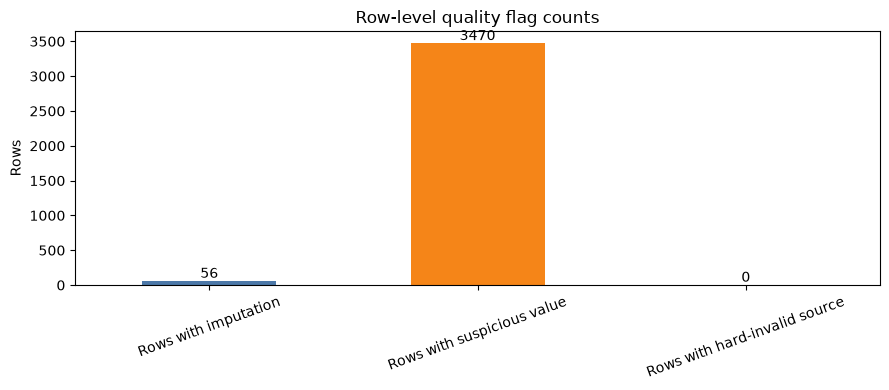

In [36]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "quality" not in globals():
        quality = pd.read_csv(QUALITY_CSV, low_memory=False)

    quality_counts = pd.Series({
        "Rows with imputation": int(quality["is_imputed_any"].sum()),
        "Rows with suspicious value": int(quality["is_suspicious_any"].sum()),
        "Rows with hard-invalid source": int(
            quality["had_hard_invalid_source_any"].sum()
        ),
    })

    ax = quality_counts.plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#F58518", "#E45756"])
    ax.set_title("Row-level quality flag counts")
    ax.set_ylabel("Rows")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.bar_label(ax.containers[0], fmt="%.0f")
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; quality chart skipped.")
except FileNotFoundError as exc:
    print(f"Required CSV file is missing: {exc.filename}. Run the cleaning and audit cells first.")